In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class LinearRegressionGD():
    """
    Linear Regression model implemented using Gradient Descent.

    Parameters
    ----------
    learning_rate : float
        The step size used to update the model parameters.
    n_iters : int
        The number of Gradient Descent iterations.
    """

    def __init__(self, alpha: float, n: int) -> None:
        """
        Initialize the Linear Regression model.

        Parameters
        ----------
        learning_rate : float
            The learning rate used during training.
        n_iters : int
            The number of iterations for Gradient Descent.
        """

        self.alpha = alpha
        self.n = n
        self.theta1 = 0
        self.theta0 = 0
        self.sse_values = []

    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        """
        Train the model using Gradient Descent.

        Parameters
        ----------
        X : np.ndarray
            Training input features.
        y : np.ndarray
            Target values.

        Returns
        -------
        None
            The method updates theta_0 and theta_1 directly.
        """

        for i in range(self.n):
            y_hat = self.theta1 * x + self.theta0

            D_theta1 = (2/len(x) * np.sum((y_hat - y) * x))
            D_theta0 = (2/len(x) * np.sum(y_hat - y) * 1)

            self.theta1 -= self.alpha * D_theta1
            self.theta0 -= self.alpha * D_theta0

            sse = (np.sum((y_hat - y)**2))
            self.sse_values.append(sse)
            
        return self
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Predict target values using the learned parameters.

        Parameters
        ----------
        X : np.ndarray
            Input feature values.

        Returns
        -------
        np.ndarray
            Predicted target values.
        """

        return self.theta1 * x + self.theta0

    def plot_training(self, x: np.ndarray, y: np.ndarray) -> None:
        """
        Plot the SSE over iterations and the regression line.

        Parameters
        ----------
        X : np.ndarray
            Input feature values.
        y : np.ndarray
            Actual target values.

        Returns
        -------
        None
        """

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(range(self.n), self.sse_values, label='SSE')
        plt.xlabel('Iterations')
        plt.ylabel('SSE')
        plt.title('SSE over Iterations')

        plt.subplot(1, 2, 2)
        plt.scatter(x, y, color='blue', label='Data Points')
        y_pred = self.predict(X)
        plt.plot(x, y_pred, color='red', label='Fitted Line')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Linear Regression Fit')
        plt.legend()
        return plt.show()

In [3]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

># Explanin what X and y represent?
- X represents the house size in square meters (m²).
- y represents the house price in thousands.

In [4]:
model = LinearRegressionGD(0.001, 100)
model.fit(X, y)
print("theta 0(B) =", model.theta0)
print("theta 1(W) =", model.theta1)

theta 0(B) = -1.0055957901462392e+95
theta 1(W) = -7.326427288635144e+96


># What do theta_0 and theta_1 represent in the regression equation?

### y=θ<sub>1</sub> * X + θ<sub>0</sub>

- theta_0(B) is the intercept. It represents the predicted value of y when X = 0.
- theta_1(W) is the slope. It represents how much y changes when X increases by one unit.

In [5]:
print("The prediction of X = 70m²:", model.predict(70))

The prediction of X = 70m²: -5.129504697834747e+98


># Is the prediction reasonable based on the dataset? Why?

- No, the prediction is not reasonable based on the dataset.<br>
For a house size of 70 m², the dataset shows a price of 210 thousand. The prediction of -5.129 is very far from this value and is also negative, which is not reasonable for a house price.<br>
This indicates that the model has not converged properly with the given learning rate and number of iterations.

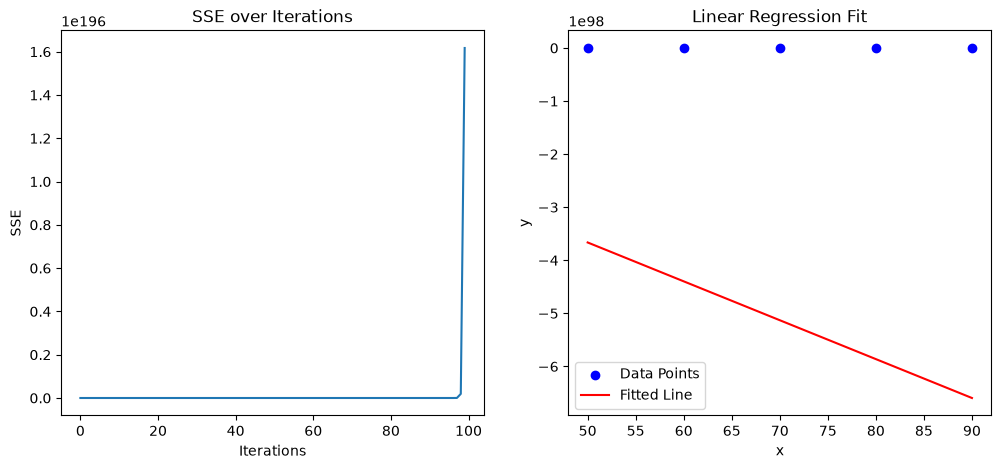

In [6]:
model.plot_training(X, y)

># Why SSE decreases over time?
- SSE decreases because Gradient Descent updates theta_0 and theta_1 in the direction that reduces the prediction error.<br>
As the model learns better values for the parameters, the predictions become closer to the actual values, so the total squared error decreases.

># What convergence means in Gradient Descent?
- Convergence means that the model parameters reach a point where the SSE stops decreasing significantly.<br>
In other words, Gradient Descent has reached a value close to the minimum error, so further iterations produce only very small improvements.

C:\Users\Fahd\AppData\Local\Temp\ipykernel_17704\649223157.py:57: RuntimeWarning: overflow encountered in square
  sse = (np.sum((y_hat - y)**2))


The SSE final value: inf


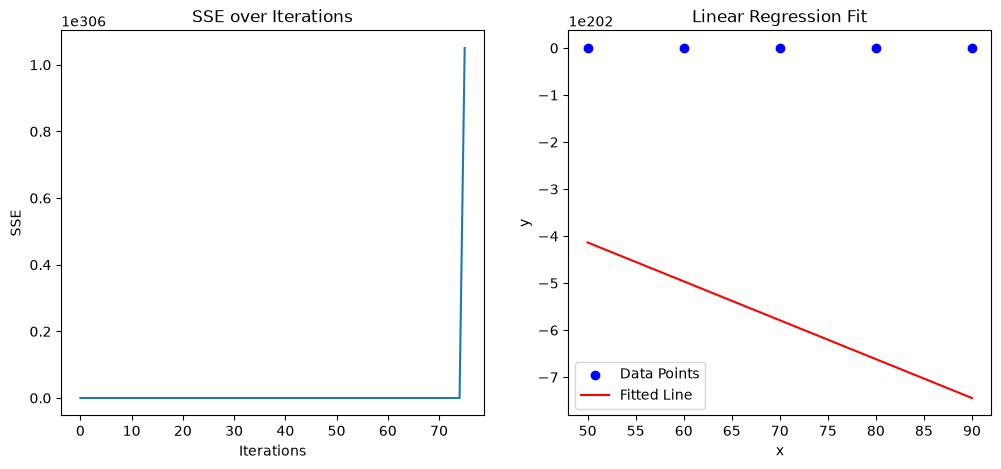

In [7]:
# Very large learning rate
model_2 = LinearRegressionGD(0.01, 100)
model_2.fit(X, y)
print("The SSE final value:", model_2.sse_values[-1])
print("="*50)
model_2.plot_training(X, y)

The SSE final value: 0.00046041150816733306


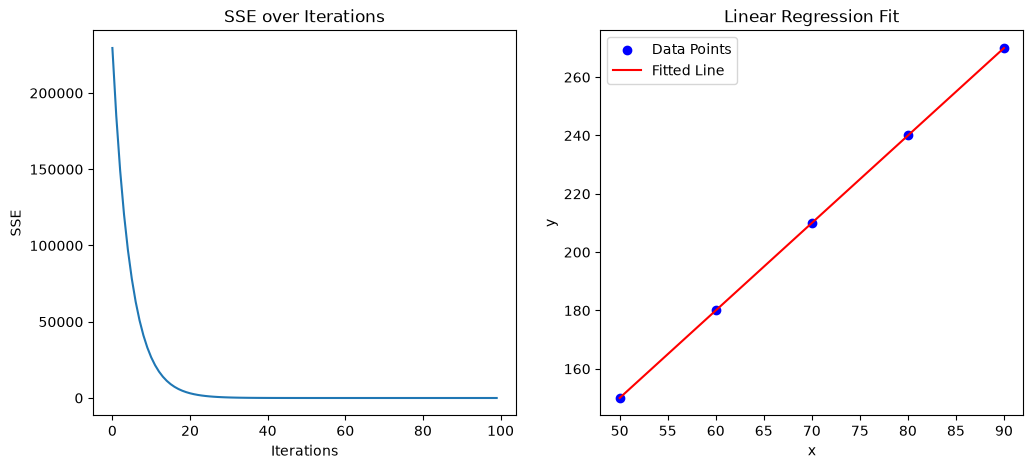

In [8]:
# Very small learning rate
model_3 = LinearRegressionGD(0.00001, 100)
model_3.fit(X, y)
print("The SSE final value:", model_3.sse_values[-1])
print("="*50)
model_3.plot_training(X, y)

| Learning Rate | Convergence Speed          | Final SSE                              |
|---------------|----------------------------|----------------------------------------|
| Large `0.01`  | Faster, but may overshoot  | May be very large or may not converge  |
| Small `0.00001` | Slower                   | May require more iterations            |

># What happens if the learning rate is too large?

- If the learning rate is too large, Gradient Descent may overshoot the minimum.<br>
This can cause the values of the parameters and SSE to increase rapidly, preventing the model from converging.<br>
In extreme cases, it can cause an overflow.

# Bouns Part ↓
- Add a method to calculate MSE
- Normalize X before training and compare results 

In [9]:
class LinearRegressionGD():
    """
    Linear Regression model implemented using Gradient Descent.

    Parameters
    ----------
    learning_rate : float
        The step size used to update the model parameters.
    n_iters : int
        The number of Gradient Descent iterations.
    """

    def __init__(self, alpha: float, n: int) -> None:
        """
        Initialize the Linear Regression model.

        Parameters
        ----------
        learning_rate : float
            The learning rate used during training.
        n_iters : int
            The number of iterations for Gradient Descent.
        """

        self.alpha = alpha
        self.n = n
        self.theta1 = 0
        self.theta0 = 0
        self.sse_values = []

    def fit(self, x: np.ndarray, y: np.ndarray) -> None:
        """
        Train the model using Gradient Descent.

        Parameters
        ----------
        X : np.ndarray
            Training input features.
        y : np.ndarray
            Target values.

        Returns
        -------
        None
            The method updates theta_0 and theta_1 directly.
        """

        for i in range(self.n):
            y_hat = self.theta1 * x + self.theta0

            D_theta1 = (2/len(x) * np.sum((y_hat - y) * x))
            D_theta0 = (2/len(x) * np.sum(y_hat - y) * 1)

            self.theta1 -= self.alpha * D_theta1
            self.theta0 -= self.alpha * D_theta0

            sse = (np.sum((y_hat - y)**2))
            self.sse_values.append(sse)
            
        return self

    # Bouns Point
    def mse(self, x: np.ndarray, y: np.ndarray) -> float:
        """
        Calculate the Mean Squared Error (MSE).

        Parameters
        ----------
        X : np.ndarray
            Input feature values.
        y : np.ndarray
            Actual target values.

        Returns
        -------
        float
            The Mean Squared Error.
        """

        y_pred = self.predict(x)
        return np.mean((y_pred - y)**2)
    
    def predict(self, x: np.ndarray) -> np.ndarray:
        """
        Predict target values using the learned parameters.

        Parameters
        ----------
        X : np.ndarray
            Input feature values.

        Returns
        -------
        np.ndarray
            Predicted target values.
        """

        return self.theta1 * x + self.theta0

    def plot_training(self, x: np.ndarray, y: np.ndarray) -> None:
        """
        Plot the SSE over iterations and the regression line.

        Parameters
        ----------
        X : np.ndarray
            Input feature values.
        y : np.ndarray
            Actual target values.

        Returns
        -------
        None
        """

        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(range(self.n), self.sse_values, label='SSE')
        plt.xlabel('Iterations')
        plt.ylabel('SSE')
        plt.title('SSE over Iterations')

        plt.subplot(1, 2, 2)
        plt.scatter(x, y, color='blue', label='Data Points')
        y_pred = self.predict(X)
        plt.plot(x, y_pred, color='red', label='Fitted Line')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Linear Regression Fit')
        plt.legend()
        return plt.show()

In [10]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

In [11]:
X_norm = (X - np.mean(X))/np.std(X)

the MSE = 30755.369070566067


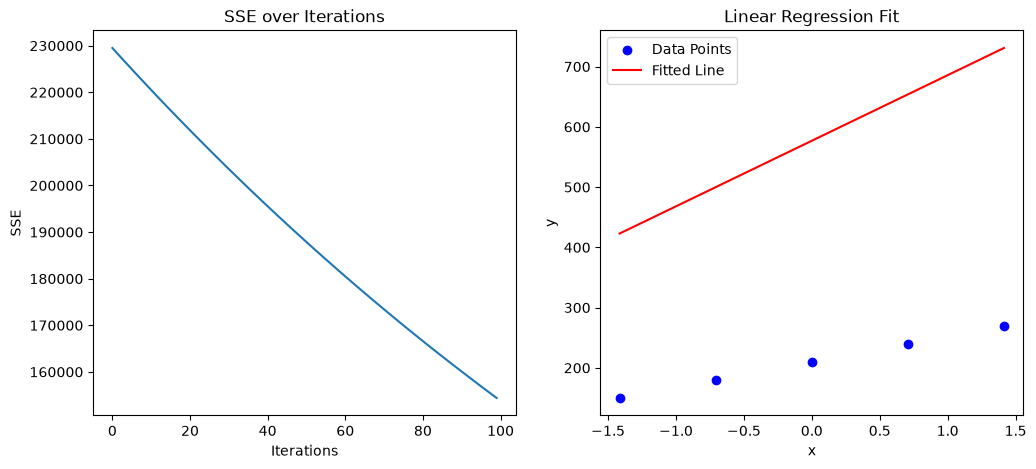

In [14]:
model_4 = LinearRegressionGD(0.001, 100)
model_4.fit(X_norm, y)
print("the MSE =", model_4.mse(X_norm, y))
model_4.plot_training(X_norm, y)